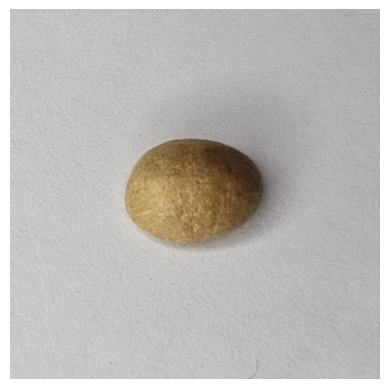

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
DATASET_DIR = BASE_DIR / "dataset_binario"
OUTPUT_SEG_DIR = BASE_DIR / "outputs" / "segmentacao"

OUTPUT_SEG_DIR.mkdir(parents=True, exist_ok=True)

img_path = list((DATASET_DIR / "ok").glob("*"))[0]

img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [2]:
def segmentar_hsv(img_bgr):
    """
    Entrada:
        img_bgr: imagem lida pelo OpenCV.

    Saída:
        mask_final: máscara binária do grão.
    """

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # TODO: ajustar estes valores conforme o dataset.
    # Teste com cv2.imshow ou matplotlib para observar a máscara.
    lower = np.array([0, 20, 20])
    upper = np.array([40, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5, 5), np.uint8)

    
    # Remove pequenos ruídos.
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Fecha pequenas falhas dentro do grão.
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

In [3]:
def segmentar_otsu(img_bgr):
    """
    Segmentação alternativa usando escala de cinza e Otsu.
    """

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    _, mask = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    kernel = np.ones((5, 5), np.uint8)
    
    #Dependendo do fundo, pode ser necessário inverter a máscara:
    mask = cv2.bitwise_not(mask)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

In [4]:
def manter_maior_contorno(mask):
    """
    Mantém apenas o maior contorno da máscara.
    Isso ajuda quando aparecem ruídos no fundo.
    """

    contornos, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contornos) == 0:
        return mask

    maior = max(contornos, key=cv2.contourArea)

    mask_limpa = np.zeros_like(mask)
    cv2.drawContours(mask_limpa, [maior], -1, 255, thickness=-1)

    return mask_limpa

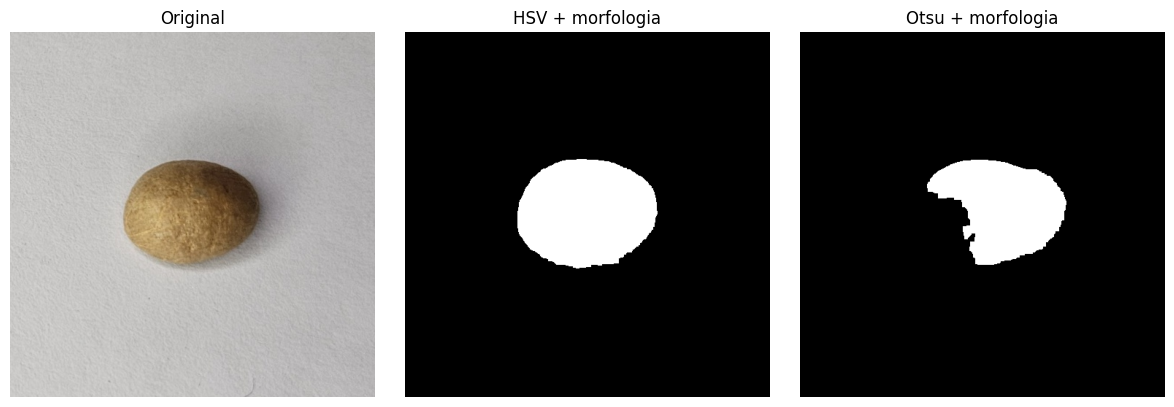

In [5]:
mask_hsv = segmentar_hsv(img_bgr)
mask_hsv = manter_maior_contorno(mask_hsv)

mask_otsu = segmentar_otsu(img_bgr)
mask_otsu = manter_maior_contorno(mask_otsu)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img_rgb)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(mask_hsv, cmap="gray")
axs[1].set_title("HSV + morfologia")
axs[1].axis("off")

axs[2].imshow(mask_otsu, cmap="gray")
axs[2].set_title("Otsu + morfologia")
axs[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
classes = ["ok", "defeituoso"]

for classe in classes:
    imagens = list((DATASET_DIR / classe).glob("*"))

    # pega só algumas imagens para exemplo
    for i, img_path in enumerate(imagens[:5], start=1):
        img_bgr = cv2.imread(str(img_path))

        if img_bgr is None:
            print(f"Erro ao ler: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        mask_hsv = segmentar_hsv(img_bgr)
        mask_hsv = manter_maior_contorno(mask_hsv)

        mask_otsu = segmentar_otsu(img_bgr)
        mask_otsu = manter_maior_contorno(mask_otsu)

        resultado_hsv = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_hsv)
        resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_otsu)

        fig, axs = plt.subplots(1, 5, figsize=(18, 4))

        axs[0].imshow(img_rgb)
        axs[0].set_title("Original")
        axs[0].axis("off")

        axs[1].imshow(mask_hsv, cmap="gray")
        axs[1].set_title("Máscara HSV")
        axs[1].axis("off")

        axs[2].imshow(resultado_hsv)
        axs[2].set_title("Resultado HSV")
        axs[2].axis("off")

        axs[3].imshow(mask_otsu, cmap="gray")
        axs[3].set_title("Máscara Otsu")
        axs[3].axis("off")

        axs[4].imshow(resultado_otsu)
        axs[4].set_title("Resultado Otsu")
        axs[4].axis("off")

        plt.tight_layout()

        nome_saida = OUTPUT_SEG_DIR / f"segmentacao_{classe}_{i:02d}.png"
        plt.savefig(nome_saida, dpi=150, bbox_inches="tight")
        plt.close()

        print(f"Salvo: {nome_saida}")

Salvo: ..\outputs\segmentacao\segmentacao_ok_01.png
Salvo: ..\outputs\segmentacao\segmentacao_ok_02.png
Salvo: ..\outputs\segmentacao\segmentacao_ok_03.png
Salvo: ..\outputs\segmentacao\segmentacao_ok_04.png
Salvo: ..\outputs\segmentacao\segmentacao_ok_05.png
Salvo: ..\outputs\segmentacao\segmentacao_defeituoso_01.png
Salvo: ..\outputs\segmentacao\segmentacao_defeituoso_02.png
Salvo: ..\outputs\segmentacao\segmentacao_defeituoso_03.png
Salvo: ..\outputs\segmentacao\segmentacao_defeituoso_04.png
Salvo: ..\outputs\segmentacao\segmentacao_defeituoso_05.png
